In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path

DATA_DIR = Path('../archive')
random.seed(42)
plt.rcParams['figure.dpi'] = 120

In [2]:
import os
import shutil

classes_manter = {
    "Full Black",
    "Partial Black",
    "Immature",
    "Broken",
    "Shell",
    "Full Sour",
    "Partial Sour",
    "Fungus Damage",
    "Slight Insect Damage",
    "Severe Insect Damage"
}

for pasta in os.listdir(DATA_DIR):

    caminho_pasta = os.path.join(DATA_DIR, pasta)

    if os.path.isdir(caminho_pasta):

        if pasta not in classes_manter:
            shutil.rmtree(caminho_pasta)
            print(f"Removido: {pasta}")

In [3]:
def segmentar_grao(caminho):
    bgr = cv2.imread(caminho)
    if bgr is None:
        raise FileNotFoundError(f"Imagem não encontrada: {caminho}")

    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)

    kernel_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_open)

    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel_close)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closed, connectivity=8)
    if num_labels <= 1:
        mask = closed
    else:
        areas = stats[1:, cv2.CC_STAT_AREA]
        max_idx = np.argmax(areas) + 1
        mask = np.zeros_like(closed, dtype=np.uint8)
        mask[labels == max_idx] = 255

    return bgr, gray, mask


def desenhar_contorno(bgr, mask, color=(0, 255, 0), thickness=2):
    im = bgr.copy()
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return im
    c = max(contours, key=cv2.contourArea)
    cv2.drawContours(im, [c], -1, color, thickness)
    return im

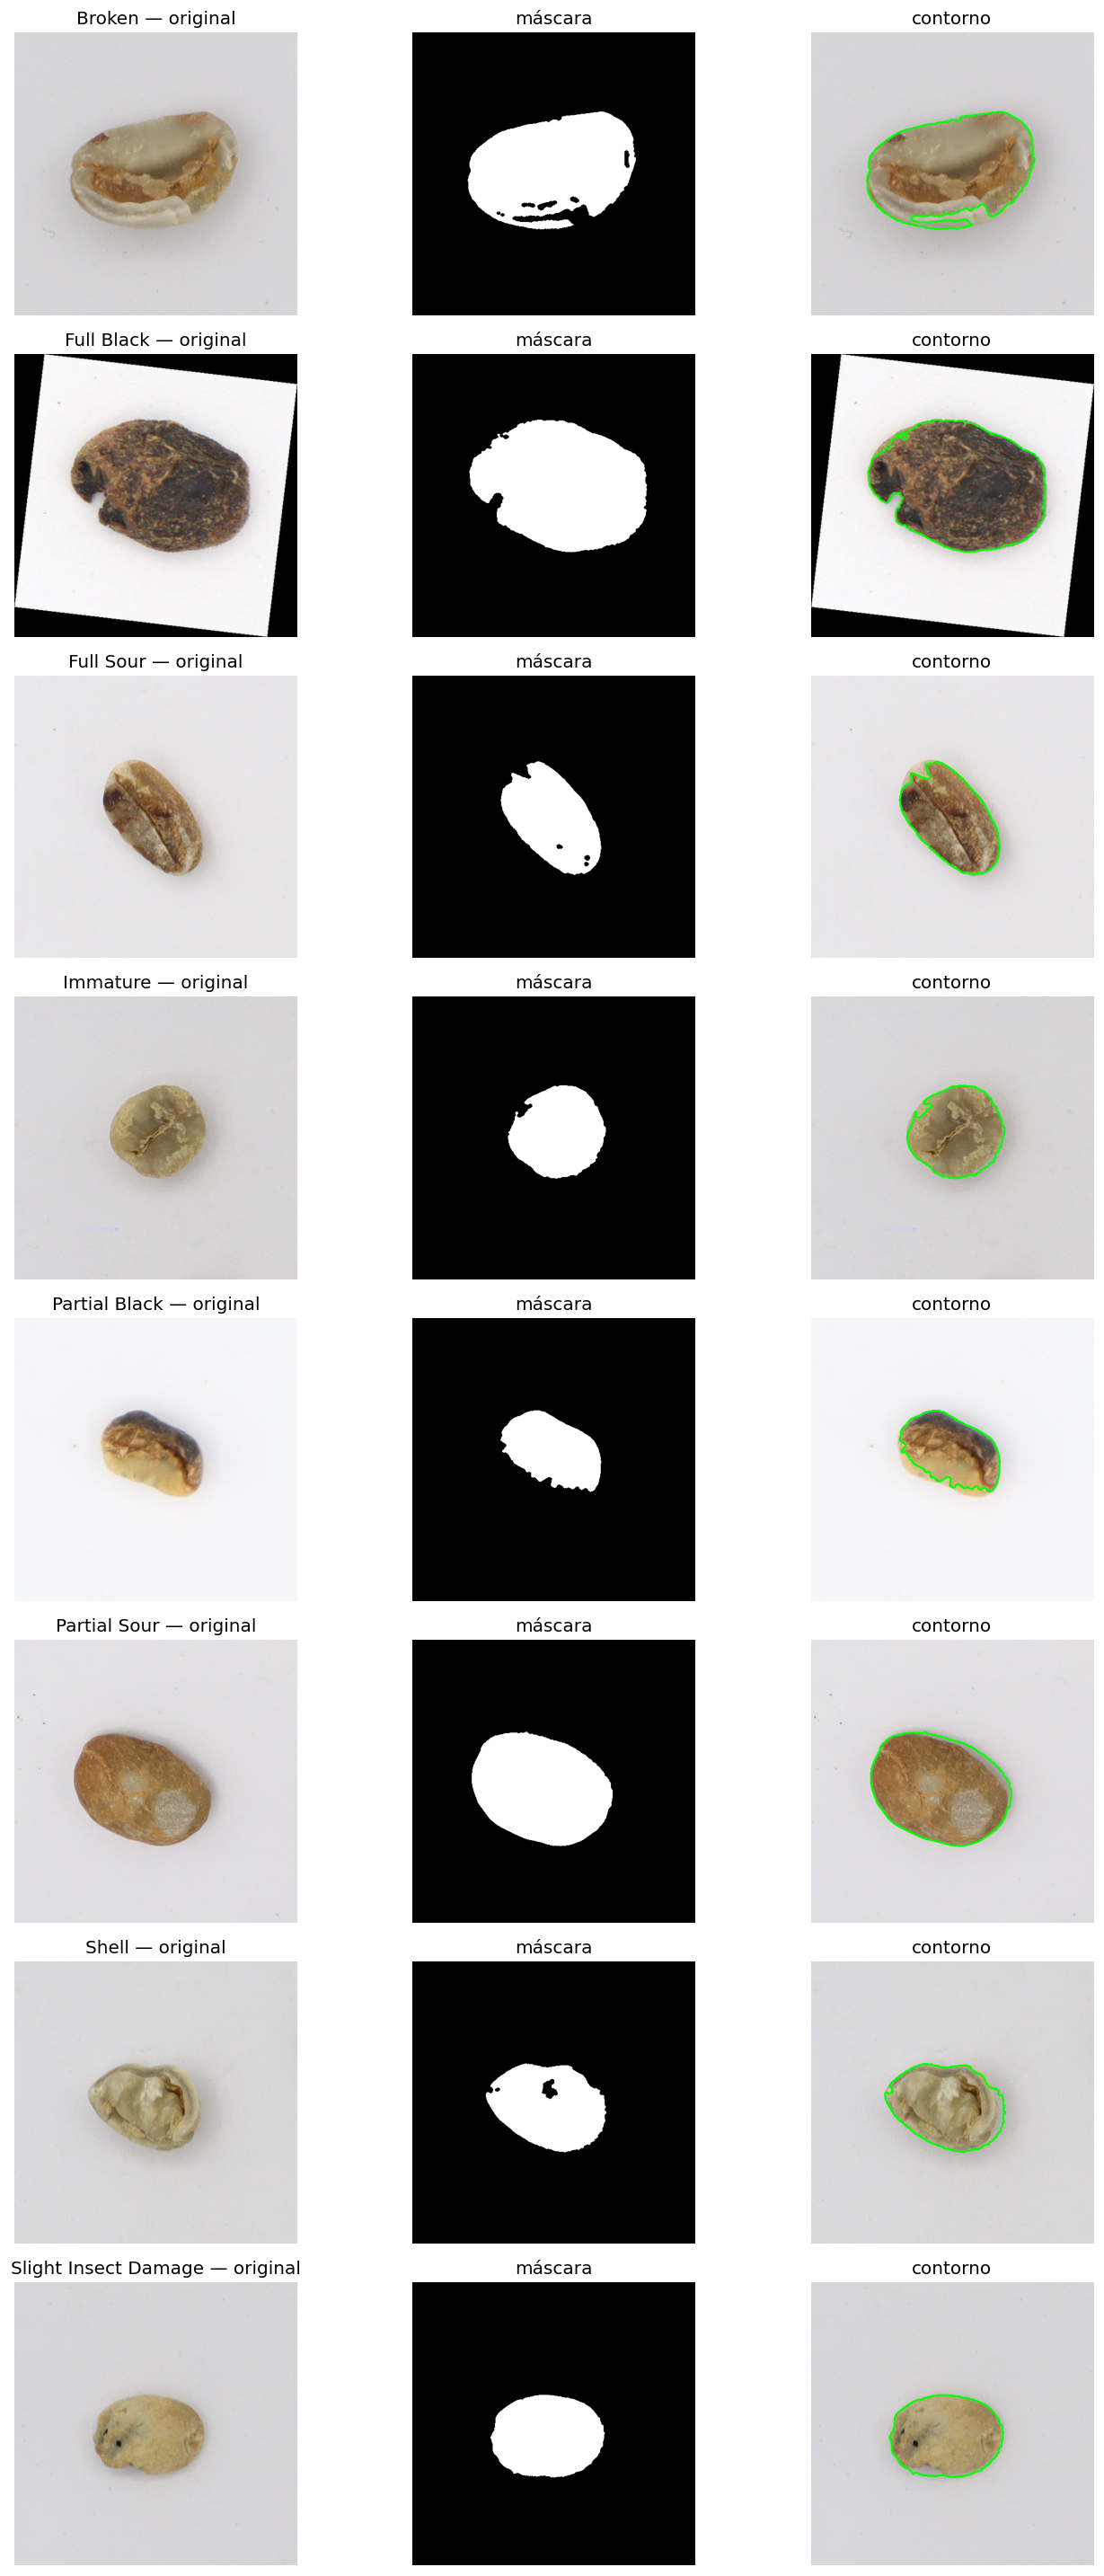

In [4]:
class_dirs = sorted([p for p in DATA_DIR.iterdir() if p.is_dir()])

fig, axes = plt.subplots(len(class_dirs), 3, figsize=(12, len(class_dirs)*3))

for i, cls_dir in enumerate(class_dirs):
    imagens = list(cls_dir.glob('*.jpg'))
    if not imagens:
        continue
    img_path = str(imagens[0])
    bgr, gray, mask = segmentar_grao(img_path)
    contorno = desenhar_contorno(bgr, mask)

    axes[i,0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    axes[i,0].set_title(f'{cls_dir.name} — original')
    axes[i,1].imshow(mask, cmap='gray')
    axes[i,1].set_title('máscara')
    axes[i,2].imshow(cv2.cvtColor(contorno, cv2.COLOR_BGR2RGB))
    axes[i,2].set_title('contorno')
    for ax in axes[i]:
        ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/figuras/segmentacao_exemplos.png')
plt.show()